In [2]:
import pandas as pd

window_label = ["5kb","10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

ols_all_df_neg = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_neg_df_ct_time.csv")
ols_all_df_pos = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_pos_df_ct_time.csv")
ols_all_df_combined = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_range_df_ct_time.csv")

In [19]:
len(ols_all_df_pos["gene"].unique())

19162

In [20]:
len(ols_all_df_neg["gene"].unique())

19161

In [21]:
len(ols_all_df_combined["gene"].unique())

19166

In [3]:
print(ols_all_df_neg.head())
print(ols_all_df_pos.head())
print(ols_all_df_combined.head())

  window   gene           peak      coef      pval         category
0    5kb  rpl24  1-11007-12962  0.018641  0.126230  non-significant
1    5kb  rpl24  1-13276-13705 -0.008529  0.456906  non-significant
2    5kb  rpl24  1-14059-14260 -0.005875  0.714421  non-significant
3    5kb  rpl24  1-14625-15105 -0.023346  0.102244  non-significant
4    5kb  rpl24  1-15724-15934  0.012797  0.235015  non-significant
  window   gene           peak      coef      pval         category
0    5kb  rpl24    1-9541-9969 -0.011703  0.236921  non-significant
1    5kb  cep97  1-13276-13705  0.031336  0.023105    sig. positive
2    5kb  cep97  1-14059-14260 -0.008766  0.619508  non-significant
3    5kb  cep97  1-14625-15105  0.019718  0.251169  non-significant
4    5kb  cep97  1-15724-15934 -0.018076  0.171329  non-significant
  window  gene                peak      coef      pval         category
0    5kb  a1cf  12-6176521-6177141  0.029794  0.501727  non-significant
1    5kb  a1cf  12-6174866-6175973 -0.05

# Assignments between increasing windows respectively (pos/neg windows)


Downstream (pos) windows

In [31]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the ols results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_pos = ols_all_df_pos[ols_all_df_pos["category"].isin(["sig. negative", "sig. positive"])]

sig_peaks_by_gene_window_pos = {}

for window in window_sizes:
    sig_peaks_by_gene_window_pos[window] = {}
    window_df = sig_df_pos[sig_df_pos["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_pos[window][gene_id] = group["peak"].tolist()

In [32]:
#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe

print(sig_peaks_by_gene_window_pos["10kb"]["rpl24"])
print(ols_all_df_pos[(ols_all_df_pos["gene"] == "rpl24") & (ols_all_df_pos["window"] == "10kb") & (ols_all_df_pos["category"].isin(["sig. negative", "sig. positive"]))]["peak"].tolist())

['1-4469-7268', '1-9541-9969']
['1-4469-7268', '1-9541-9969']


In [ ]:
import numpy as np
import pandas as pd

#define functions to calculate jaccard similarity and retention between two sets of peaks

def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    intersection = len(a & b)
    union = len(a | b)
    return intersection / union if union > 0 else 0

def retention(set_small, set_large):
    a, b = set(set_small), set(set_large)
    return len(a & b) / len(a) if len(a) > 0 else 0

#compare the significant peaks for each gene between the 10kb window and each of the larger windows, calculating jaccard similarity and retention, and store the results in a dataframe
results = []

for window in window_sizes[1:]:  # compare each window against 10kb
    for gene_id in sig_peaks_by_gene_window_pos["10kb"].keys():
        base_peaks = sig_peaks_by_gene_window_pos["10kb"].get(gene_id, [])
        compare_peaks = sig_peaks_by_gene_window_pos[window].get(gene_id, [])

        j = jaccard(base_peaks, compare_peaks)
        r = retention(base_peaks, compare_peaks)

        results.append({
            "gene_id": gene_id,
            "window": window,
            "jaccard": j,
            "retention": r,
            "n_sig_10kb": len(set(base_peaks)),
            "n_sig_window": len(set(compare_peaks)),
            "n_intersection": len(set(base_peaks) & set(compare_peaks))
        })

results_df = pd.DataFrame(results)


In [34]:
sig_peaks_by_gene_window_pos

{'5kb': {'aanat1': ['6-23615580-23616657'],
  'aasdhppt': ['15-44462428-44463047'],
  'abca12': ['9-40844746-40845090'],
  'abcc8': ['25-22721310-22721509'],
  'abce1': ['23-43716170-43716760'],
  'abcg2b': ['1-8689032-8689961'],
  'abhd17ab': ['8-19242901-19243634'],
  'abhd3': ['2-11909108-11909896'],
  'abhd4': ['2-51647524-51648833'],
  'abhd6a': ['11-42095685-42096673'],
  'abi1a': ['24-5938074-5938674'],
  'abi3bpb': ['22-28447400-28447991', '22-28448086-28448778'],
  'abl2': ['8-14916691-14916975'],
  'ablim3': ['14-34768797-34769924'],
  'abr': ['5-62377086-62377521'],
  'acaca': ['5-56411573-56412317'],
  'acadl': ['18-39490350-39490794'],
  'acadm': ['2-26473708-26474182'],
  'acads': ['10-44015462-44016090'],
  'acbd7': ['16-28599141-28599624'],
  'ackr3a': ['9-24048083-24049201'],
  'acod1': ['9-21833543-21834637'],
  'acot14': ['4-25607831-25608165'],
  'acsl4b': ['5-23572477-23572694'],
  'acsl5': ['12-31459375-31460088'],
  'acta1a': ['1-53947797-53948697', '1-53949316-5

In [35]:
# pick any gene and check its 10kb peaks compared to itself
gene = list(sig_peaks_by_gene_window_pos["10kb"].keys())[0]
peaks = sig_peaks_by_gene_window_pos["10kb"][gene]
print(f"gene: {gene}")
print(f"peaks: {peaks}")
print(f"n peaks: {len(peaks)}")
print(f"n unique peaks: {len(set(peaks))}")
print(f"jaccard with itself: {jaccard(peaks, peaks)}")

gene: aak1a
peaks: ['8-48970069-48970933']
n peaks: 1
n unique peaks: 1
jaccard with itself: 1.0


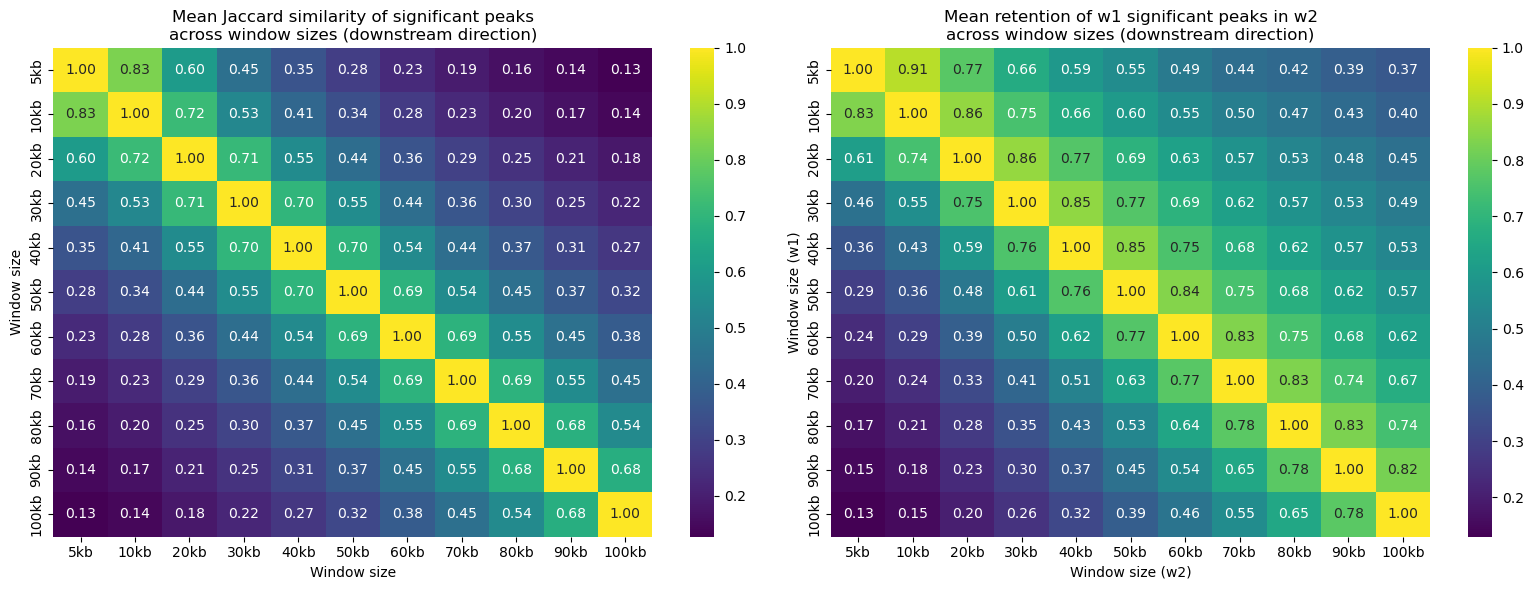

In [ ]:
#create a heatmap of the mean retention for each pair of window sizes, by calculating the retention for each gene and averaging across all genes for each pair of window sizes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_genes = set(ols_all_df_pos["gene"].unique())

# --- Jaccard matrix ---
jaccard_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            jaccard( #compute gene-wise jaccard similarity between the significant peaks for the two window sizes, only for genes that have significant peaks in both window sizes
                sig_peaks_by_gene_window_pos[w1].get(gene, []),
                sig_peaks_by_gene_window_pos[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_pos[w1].get(gene, [])) > 0  #only consider genes that have significant peaks in both window sizes
            and len(sig_peaks_by_gene_window_pos[w2].get(gene, [])) > 0
        ]
        jaccard_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan #average the jaccard similarity across all genes for the pair of window sizes, and store in the matrix

# --- Retention matrix (how many peaks from w1 are retained in w2) ---
retention_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            retention(
                sig_peaks_by_gene_window_pos[w1].get(gene, []),
                sig_peaks_by_gene_window_pos[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_pos[w1].get(gene, [])) > 0
            and len(sig_peaks_by_gene_window_pos[w2].get(gene, [])) > 0
        ]
        retention_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan 

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("Window size")
axes[0].set_title("Mean Jaccard similarity of significant peaks\nacross window sizes (downstream direction)")

sns.heatmap(retention_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("Window size (w2)")
axes[1].set_ylabel("Window size (w1)")
axes[1].set_title("Mean retention of w1 significant peaks in w2\nacross window sizes (downstream direction)")

plt.tight_layout()

**The heatmap (left)** shows the **mean Jaccard similarity** between windows: "measuring the stability of peak selection as the window sizes increases around the TSS"
1. For every window size and gene, I created a set of significant peaks from the OLS results. (Here the significance direction, whether it is negative/positive was ignored)
2. Created a list of all genes present in any windows 
3. Computed Jaccard similarity of the significant peak set of one gene between two windows (Only genes having at least one significant peak in both windows were included)
4. Averaged across all genes

Jaccard = Intersection/Union (Overlapping set/global set)

The heatmap shows how stable the selected significant peaks (by ols) for a typical gene are, if the window size used for peak assignment is changed.
High Jaccard between two windows = most genes keep similar significant peaks
Low Jaccard between two windows = most genes gain/lose significant peaks when the window size increases --> retention matrix!


**The heatmap (right)** shows the **mean Retention** between window 1 (w1) and 2 (w2): "Measuring the fraction of selected peaks"
The retention matrix is asymmetric: meaning the interpretation depends on which direction you read it

Row (w1) = the reference set (window, whose peaks are tracked)
Column (w2) = the comparison set (window, in which retention is checked)
Cell value = fraction of w1 significant peaks that are also significant in w2

Interpreting patterns:

Upper triangle (w1 < w2, e.g. row=10kb, col=100kb)

"How many 10kb significant peaks are still significant in the 100kb window?"
- High value → small window peaks are stable as window grows; Jaccard drops because new peaks are added in larger windows
- Low value → small window peaks are lost as window grows; Jaccard drops because peaks become non-significant in larger contexts

Lower triangle (w1 > w2, e.g. row=100kb, col=10kb)

"How many 100kb significant peaks are also significant in the 10kb window?"
- High value → large window significant peaks were already detectable in small windows
- Low value → large window significant peaks are newly emerging and not present in smaller windows

A high value at (10kb, 100kb) means most 10kb significant peaks are still significant in the 100kb window → Jaccard drop is driven by new peaks added, not loss of original peaks
A low value at (10kb, 100kb) means 10kb peaks are lost in the 100kb window → Jaccard drop is driven by non-overlapping peaks



Combining Jaccard and Retention: 
Jaccard = overall similarity of selected peak sets
Retention = stability of peaks discovered in the smaller window

Both together: If retention stays high but Jaccard drops, the larger windows are mostly adding peaks rather than replacing them.


**Jaccard heatmap (left)**

- The diagonal is 1.0 — correctly fixed
- Jaccard drops steadily as window size difference increases, e.g. 5kb vs 100kb = 0.13, meaning only 13% of significant peaks are shared between the smallest and largest windows
- Adjacent windows (e.g. 5kb→10kb = 0.83, 90kb→100kb = 0.68) retain high similarity, suggesting the significant peak set changes **gradually** rather than abruptly at any specific window size
- No sharp transition point — the decay is smooth across all window pairs

**Retention heatmap (right)**

- Upper triangle values are consistently **higher than the corresponding Jaccard values** — e.g. 5kb→100kb Jaccard = 0.13 but retention = 0.37
- This means a meaningful fraction of small-window significant peaks **survive** into larger windows, but they become a small proportion of the total significant peak set
- Lower triangle values are low — e.g. 100kb→5kb retention = 0.13 — confirming that most large-window significant peaks are **not detectable** in smaller windows

**Overall conclusion**

The Jaccard drop as window size grows is primarily driven by **new peaks being added** in larger windows rather than loss of originally significant peaks. The core set of significant peaks identified in small windows is partially retained, but gets diluted by the increasing number of newly significant distal peaks. This suggests:

- Small windows (5–20kb) capture a **stable, robust core** of promoter-proximal significant peaks
- Larger windows progressively incorporate distal regulatory elements, but at the cost of set coherence
- For your thesis, this supports using a **defined window cutoff** (e.g. 20–30kb) where Jaccard still remains relatively high (0.60–0.71) while capturing a reasonable regulatory range

Upstream (neg) windows

In [63]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the ols results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_neg = ols_all_df_neg[ols_all_df_neg["category"].isin(["sig. negative", "sig. positive"])]

sig_peaks_by_gene_window_neg = {}

for window in window_sizes:
    sig_peaks_by_gene_window_neg[window] = {}
    window_df = sig_df_neg[sig_df_neg["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_neg[window][gene_id] = group["peak"].tolist()

In [ ]:
#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe
print(sig_peaks_by_gene_window_neg["10kb"]["abcc10"])
print(ols_all_df_neg[(ols_all_df_neg["gene"] == "abcc10") & (ols_all_df_neg["window"] == "10kb") & (ols_all_df_neg["category"].isin(["sig. negative", "sig. positive"]))]["peak"].tolist())

['11-11965923-11966247', '11-11968657-11969200']
['11-11965923-11966247', '11-11968657-11969200']


In [ ]:
import numpy as np
import pandas as pd

#define functions to calculate jaccard similarity and retention between two sets of peaks

def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    intersection = len(a & b)
    union = len(a | b)
    return intersection / union if union > 0 else 0

def retention(set_small, set_large):
    a, b = set(set_small), set(set_large)
    return len(a & b) / len(a) if len(a) > 0 else 0


In [67]:
# pick any gene and check its 10kb peaks compared to itself
gene = list(sig_peaks_by_gene_window_neg["10kb"].keys())[0]
peaks = sig_peaks_by_gene_window_neg["10kb"][gene]
print(f"gene: {gene}")
print(f"peaks: {peaks}")
print(f"n peaks: {len(peaks)}")
print(f"n unique peaks: {len(set(peaks))}")
print(f"jaccard with itself: {jaccard(peaks, peaks)}")

gene: aaas
peaks: ['9-249047-250089']
n peaks: 1
n unique peaks: 1
jaccard with itself: 1.0


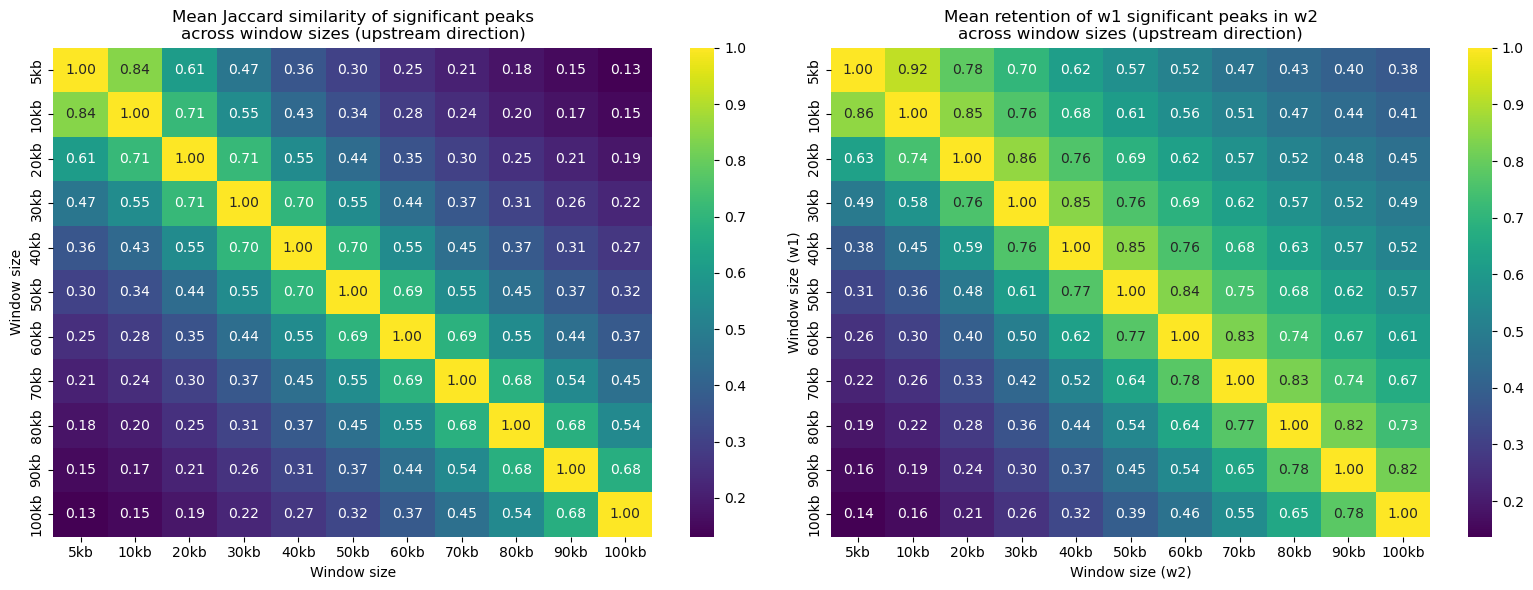

In [69]:
#create a heatmap of the mean retention for each pair of window sizes, by calculating the retention for each gene and averaging across all genes for each pair of window sizes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_genes = set(ols_all_df_neg["gene"].unique())

# --- Jaccard matrix ---
jaccard_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            jaccard( #compute gene-wise jaccard similarity between the significant peaks for the two window sizes, only for genes that have significant peaks in both window sizes
                sig_peaks_by_gene_window_neg[w1].get(gene, []),
                sig_peaks_by_gene_window_neg[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_neg[w1].get(gene, [])) > 0  #only consider genes that have significant peaks in both window sizes
            and len(sig_peaks_by_gene_window_neg[w2].get(gene, [])) > 0
        ]
        jaccard_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan #average the jaccard similarity across all genes for the pair of window sizes, and store in the matrix

# --- Retention matrix (how many peaks from w1 are retained in w2) ---
retention_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            retention(
                sig_peaks_by_gene_window_neg[w1].get(gene, []),
                sig_peaks_by_gene_window_neg[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_neg[w1].get(gene, [])) > 0
            and len(sig_peaks_by_gene_window_neg[w2].get(gene, [])) > 0
        ]
        retention_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan 

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("Window size")
axes[0].set_title("Mean Jaccard similarity of significant peaks\nacross window sizes (upstream direction)")

sns.heatmap(retention_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("Window size (w2)")
axes[1].set_ylabel("Window size (w1)")
axes[1].set_title("Mean retention of w1 significant peaks in w2\nacross window sizes (upstream direction)")

plt.tight_layout()


Overlap window around TSS

In [70]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the ols results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_combined = ols_all_df_combined[ols_all_df_combined["category"].isin(["sig. negative", "sig. positive"])]

sig_peaks_by_gene_window_combined = {}

for window in window_sizes:
    sig_peaks_by_gene_window_combined[window] = {}
    window_df = sig_df_combined[sig_df_combined["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_combined[window][gene_id] = group["peak"].tolist()

In [71]:
#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe
print(sig_peaks_by_gene_window_combined["10kb"]["abcc10"])
print(ols_all_df_combined[(ols_all_df_combined["gene"] == "abcc10") & (ols_all_df_combined["window"] == "10kb") & (ols_all_df_combined["category"].isin(["sig. negative", "sig. positive"]))]["peak"].tolist())

['11-11965923-11966247', '11-11968657-11969200']
['11-11965923-11966247', '11-11968657-11969200']


In [72]:
# pick any gene and check its 10kb peaks compared to itself
gene = list(sig_peaks_by_gene_window_combined["10kb"].keys())[0]
peaks = sig_peaks_by_gene_window_combined["10kb"][gene]
print(f"gene: {gene}")
print(f"peaks: {peaks}")
print(f"n peaks: {len(peaks)}")
print(f"n unique peaks: {len(set(peaks))}")
print(f"jaccard with itself: {jaccard(peaks, peaks)}")

gene: aaas
peaks: ['9-249047-250089']
n peaks: 1
n unique peaks: 1
jaccard with itself: 1.0


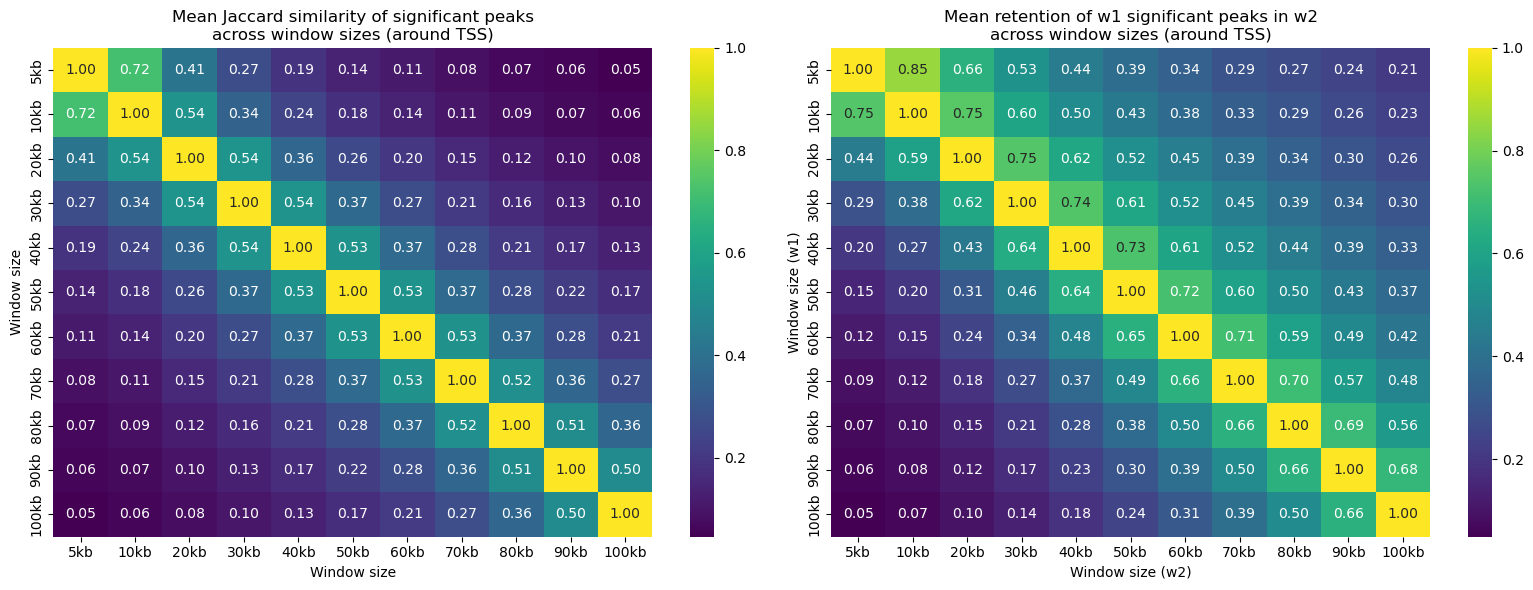

In [73]:
#create a heatmap of the mean retention for each pair of window sizes, by calculating the retention for each gene and averaging across all genes for each pair of window sizes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_genes = set(ols_all_df_combined["gene"].unique())

# --- Jaccard matrix ---
jaccard_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            jaccard( #compute gene-wise jaccard similarity between the significant peaks for the two window sizes, only for genes that have significant peaks in both window sizes
                sig_peaks_by_gene_window_combined[w1].get(gene, []),
                sig_peaks_by_gene_window_combined[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_combined[w1].get(gene, [])) > 0  #only consider genes that have significant peaks in both window sizes
            and len(sig_peaks_by_gene_window_combined[w2].get(gene, [])) > 0
        ]
        jaccard_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan #average the jaccard similarity across all genes for the pair of window sizes, and store in the matrix

# --- Retention matrix (how many peaks from w1 are retained in w2) ---
retention_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            retention(
                sig_peaks_by_gene_window_combined[w1].get(gene, []),
                sig_peaks_by_gene_window_combined[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_combined[w1].get(gene, [])) > 0
            and len(sig_peaks_by_gene_window_combined[w2].get(gene, [])) > 0
        ]
        retention_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan 

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("Window size")
axes[0].set_title("Mean Jaccard similarity of significant peaks\nacross window sizes (around TSS)")

sns.heatmap(retention_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("Window size (w2)")
axes[1].set_ylabel("Window size (w1)")
axes[1].set_title("Mean retention of w1 significant peaks in w2\nacross window sizes (around TSS)")

plt.tight_layout()

# Assignments between neg. + pos. windows and combined window

In [ ]:
#merge both datasets of monodirectional dfs 
combined_df = pd.concat([ols_all_df_neg, ols_all_df_pos], ignore_index=True)
combined_df.head()

#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe
gene_id = "rpl24"
window = "10kb"

sig_peaks_list = list(set(ols_all_df_neg[(ols_all_df_neg["window"] == window) & (ols_all_df_neg["gene"] == gene_id)]["peak"].tolist()) | set(ols_all_df_pos[(ols_all_df_pos["window"] == window) & (ols_all_df_pos["gene"] == gene_id)]["peak"].tolist()))
sig_peaks_df = combined_df[(combined_df["gene"] == gene_id) & (combined_df["window"] == window)]["peak"].tolist()

print(f"Significant peaks for {gene_id} in {window}: sig_peaks_list: {sig_peaks_list}")
print(f"From dataframe: {sig_peaks_df}")


Significant peaks for rpl24 in 10kb: sig_peaks_list: ['1-14625-15105', '1-2372-3057', '1-13276-13705', '1-17587-18215', '1-16762-17233', '1-18372-20466', '1-14059-14260', '1-15724-15934', '1-3427-4032', '1-4469-7268', '1-21199-21555', '1-11007-12962', '1-9541-9969']
From dataframe: ['1-11007-12962', '1-13276-13705', '1-14059-14260', '1-14625-15105', '1-15724-15934', '1-16762-17233', '1-17587-18215', '1-18372-20466', '1-21199-21555', '1-2372-3057', '1-3427-4032', '1-4469-7268', '1-9541-9969']


In [ ]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the ols results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_unidir = combined_df[combined_df["category"].isin(["sig. negative", "sig. positive"])] 

sig_peaks_by_gene_window_unidir = {}

for window in window_sizes:
    sig_peaks_by_gene_window_unidir[window] = {}
    window_df = sig_df_unidir[sig_df_unidir["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_unidir[window][gene_id] = group["peak"].tolist()

In [77]:
#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe

print(sig_peaks_by_gene_window_unidir["10kb"]["rpl24"])
print(combined_df[(combined_df["gene"] == "rpl24") & (combined_df["window"] == "10kb") & (combined_df["category"].isin(["sig. negative", "sig. positive"]))]["peak"].tolist())

['1-4469-7268', '1-9541-9969']
['1-4469-7268', '1-9541-9969']


In [80]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the ols results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_bidir = ols_all_df_combined[ols_all_df_combined["category"].isin(["sig. negative", "sig. positive"])]

sig_peaks_by_gene_window_real = {}

for window in window_sizes:
    sig_peaks_by_gene_window_real[window] = {}
    window_df = sig_df_bidir[sig_df_bidir["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_real[window][gene_id] = group["peak"].tolist()

In [78]:
sig_peaks_by_gene_window_unidir

{'5kb': {'aaas': ['9-249047-250089'],
  'aak1b': ['10-41155835-41157259'],
  'aamdc': ['18-3102907-3103978'],
  'aamp': ['6-59912765-59914432'],
  'aanat1': ['6-23615580-23616657'],
  'aasdhppt': ['15-44462428-44463047'],
  'aatka': ['3-52045138-52045493'],
  'abat': ['3-27882194-27883080'],
  'abca12': ['9-40847723-40848125', '9-40844746-40845090'],
  'abca1a': ['1-52559672-52561776'],
  'abca5': ['12-38806791-38807074'],
  'abcb9': ['5-28028683-28030156'],
  'abcc10': ['11-11965923-11966247', '11-11968657-11969200'],
  'abcc13': ['24-24064336-24065355'],
  'abcc2': ['13-680325-681048'],
  'abcc8': ['25-22717515-22717939',
   '25-22719626-22721119',
   '25-22721310-22721509'],
  'abcd1': ['8-8044654-8045582'],
  'abcd4': ['24-35910439-35911261'],
  'abce1': ['23-43718590-43719048', '23-43716170-43716760'],
  'abcf1': ['19-30446650-30447867'],
  'abcg2b': ['1-8689032-8689961'],
  'abcg4a': ['5-30622387-30623203'],
  'abcg8': ['13-10949799-10949998'],
  'abhd17ab': ['8-19247928-19248957

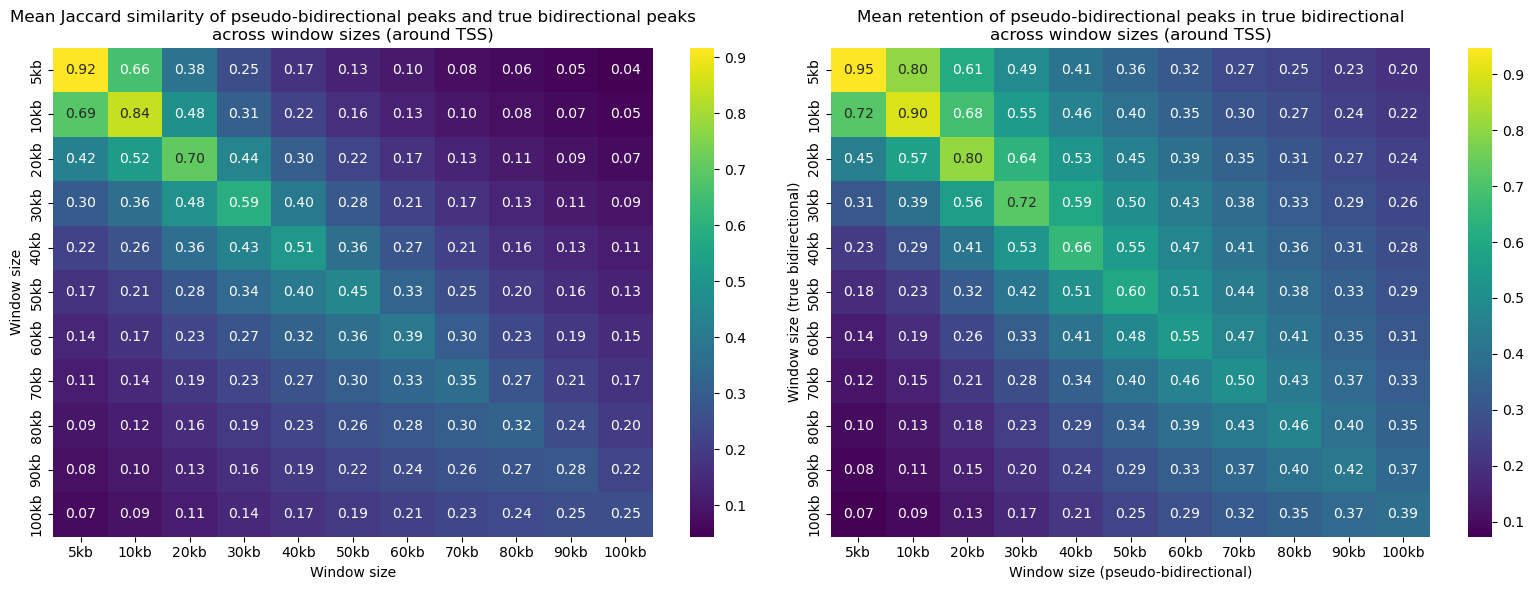

In [85]:
#create a heatmap of the mean retention for each pair of window sizes, by calculating the retention for each gene and averaging across all genes for each pair of window sizes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_genes = set(ols_all_df_combined["gene"].unique()) | set(combined_df["gene"].unique()) #take the union of the genes from both dataframes to make sure we include all genes that have significant peaks in either dataset

# --- Jaccard matrix ---
jaccard_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            jaccard( #compute gene-wise jaccard similarity between the significant peaks for the two window sizes, only for genes that have significant peaks in both window sizes
                sig_peaks_by_gene_window_unidir[w1].get(gene, []),
                sig_peaks_by_gene_window_real[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_unidir[w1].get(gene, [])) > 0  #only consider genes that have significant peaks in both window sizes
            and len(sig_peaks_by_gene_window_real[w2].get(gene, [])) > 0
        ]
        jaccard_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan #average the jaccard similarity across all genes for the pair of window sizes, and store in the matrix

# --- Retention matrix (how many peaks from w1 are retained in w2) ---
retention_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            retention(
                sig_peaks_by_gene_window_unidir[w1].get(gene, []),
                sig_peaks_by_gene_window_real[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_unidir[w1].get(gene, [])) > 0
            and len(sig_peaks_by_gene_window_real[w2].get(gene, [])) > 0
        ]
        retention_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan 

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("Window size")
axes[0].set_title("Mean Jaccard similarity of pseudo-bidirectional peaks and true bidirectional peaks\nacross window sizes (around TSS)")

sns.heatmap(retention_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("Window size (pseudo-bidirectional)")
axes[1].set_ylabel("Window size (true bidirectional)")
axes[1].set_title("Mean retention of pseudo-bidirectional peaks in true bidirectional\nacross window sizes (around TSS)")

plt.tight_layout()